# Analyse Crypto Data Pipeline
Ce notebook permet d'explorer et d'analyser les données collectées via l'API CoinGecko.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

# Connexion à la base de données
conn = sqlite3.connect('../database/crypto.db')
df = pd.read_sql('SELECT * FROM crypto_prices', conn)
conn.close()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,name,current_price,market_cap,total_volume,price_change_percentage_24h,timestamp
0,Bitcoin,68013.000000,1362778340952,33712120480,-1.07104,2026-03-23 10:36:16.557614
1,Ethereum,2033.860000,246013001719,15099034324,-2.48203,2026-03-23 10:36:16.557614
2,Tether,0.999581,184111306278,53761240154,-0.02053,2026-03-23 10:36:16.557614
3,BNB,623.080000,85093064551,945042657,-1.19612,2026-03-23 10:36:16.557614
4,XRP,1.370000,83930032279,1730343951,-2.16284,2026-03-23 10:36:16.557614


## 1. Évolution du prix des cryptos majeures

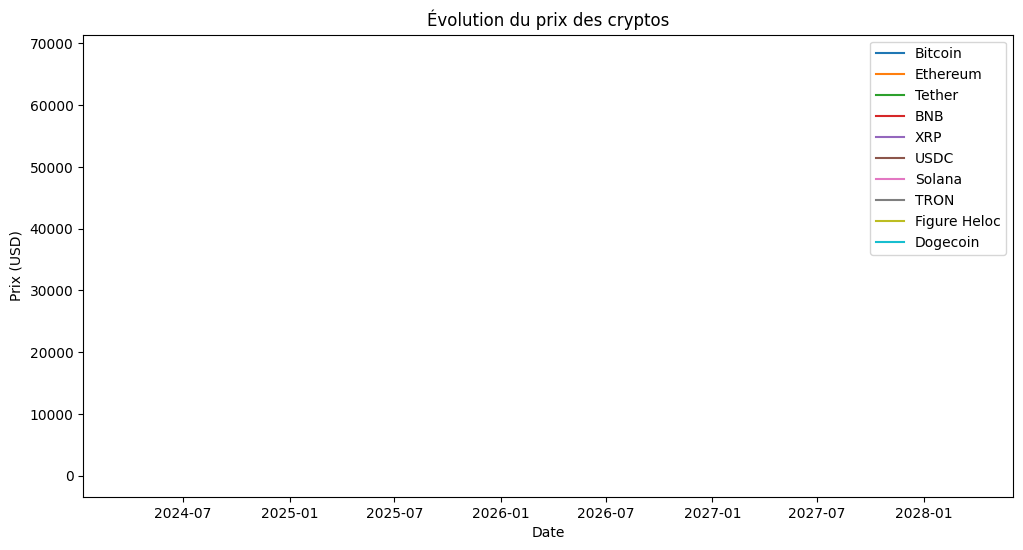

In [2]:
plt.figure(figsize=(12,6))
for name in df['name'].unique():
    plt.plot(df[df['name']==name]['timestamp'], df[df['name']==name]['current_price'], label=name)
plt.legend()
plt.title('Évolution du prix des cryptos')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.show()

## 2. Top cryptos par market cap

In [3]:
top = df[df['timestamp'] == df['timestamp'].max()].sort_values('market_cap', ascending=False)
top[['name', 'market_cap']].head(10)

,name,market_cap
0,Bitcoin,1362778340952
1,Ethereum,246013001719
2,Tether,184111306278
3,BNB,85093064551
4,XRP,83930032279
5,USDC,78882554834
6,Solana,49008271772
7,TRON,29046439309
8,Figure Heloc,15843541913
9,Dogecoin,13775578440


## 3. Variation de prix sur 24h

In [4]:
variation = df[df['timestamp'] == df['timestamp'].max()][['name', 'price_change_percentage_24h']]
variation.sort_values('price_change_percentage_24h', ascending=False)

,name,price_change_percentage_24h
5,USDC,-0.00596
2,Tether,-0.02053
7,TRON,-0.96811
0,Bitcoin,-1.07104
3,BNB,-1.19612
9,Dogecoin,-1.73639
6,Solana,-1.85107
4,XRP,-2.16284
1,Ethereum,-2.48203
8,Figure Heloc,NaN
